# Identify Energy Generator Locations

## Identify location weight for weather data aggregation

* Source: https://www.marktstammdatenregister.de/MaStR/
	- under Öffentlichen Daten
	- Filter
		- Betriebstatus = In Betrieb
		- Energieträger = Solarstrahlungsenergie or Wind
		- Bruttoleistung der Einheiten > 5000
* download csv of actual market data - energy generator register 
* identify the locations and sorted by capacitys for wind and solar generation
	- large PV parks aggregate the solor generation
	- wind parks registered as small units up to 15000
	- identify geo-cluster of the largest generators
	- center location of clusers and sum of capacity in the cluster 
* use cluster centers as selected locations for weather data search
* use capacity sum in the cluster to weight the weather data


### Load and explore the csv

* visualize the generator distribution on map of Germany
* find clusters using K-Means 
* create dictionary of coordinates and aggregated (sum of) capacities
* visualize the cluster distribution on map of Germany

In [5]:
import pandas as pd

df_gen_pv = pd.read_csv("../data/raw/Stromerzeuger_pv_20260530.csv", parse_dates=['Inbetriebnahmedatum der Einheit'], sep=";", decimal=",")
df_gen_wind = pd.read_csv("../data/raw/Stromerzeuger_wind_20260530.csv", parse_dates=['Inbetriebnahmedatum der Einheit'], sep=";", decimal=",")

# select relevant columns
cols_pv =['Anzeige-Name der Einheit', 
        'Bruttoleistung der Einheit', 
        'Nettonennleistung der Einheit', 
        'Inbetriebnahmedatum der Einheit', 
        'Bundesland', 'Postleitzahl', 'Ort', 
        'Koordinate: Breitengrad (WGS84)', 'Koordinate: Längengrad (WGS84)'
        ]

cols_wind =['Anzeige-Name der Einheit', 
        'Bruttoleistung der Einheit', 
        'Nettonennleistung der Einheit', 
        'Inbetriebnahmedatum der Einheit', 
        'Bundesland', 'Postleitzahl', 'Ort', 
        'Koordinate: Breitengrad (WGS84)', 'Koordinate: Längengrad (WGS84)', 
        'Wind an Land oder auf See'
        #'Name des Windparks', 'Elektrische KWK-Leistung'
        ]

df_gen_pv = df_gen_pv[cols_pv]
df_gen_wind = df_gen_wind[cols_wind]

df_gen_wind_land = df_gen_wind[df_gen_wind['Wind an Land oder auf See'] == 'Windkraft an Land'].copy()
df_gen_wind_sea = df_gen_wind[df_gen_wind['Wind an Land oder auf See'] == 'Windkraft auf See'].copy()

print("--- Solar ---")
display(df_gen_pv.info())
display(df_gen_pv.describe())
df_gen_pv = df_gen_pv.sort_values('Bruttoleistung der Einheit').reset_index(drop=True)
df_gen_pv.head(10)

print("--- Wind ---")
display(df_gen_wind.info())
display(df_gen_wind.describe())
df_gen_wind = df_gen_wind.sort_values('Bruttoleistung der Einheit').reset_index(drop=True)
df_gen_wind.head(10)

print("--- Wind Land ---")
display(df_gen_wind_land.info())
display(df_gen_wind_land.describe())
df_gen_wind_land = df_gen_wind_land.sort_values('Bruttoleistung der Einheit').reset_index(drop=True)
df_gen_wind_land.head(10)

print("--- Wind See ---")
display(df_gen_wind_sea.info())
display(df_gen_wind_sea.describe())
df_gen_wind_sea = df_gen_wind_sea.sort_values('Bruttoleistung der Einheit').reset_index(drop=True)
df_gen_wind_sea.head(10)
        
        
print('solar missing:\n', df_gen_pv.isna().sum())
print('wind missing:\n', df_gen_wind.isna().sum())
print('wind land missing:\n', df_gen_wind_land.isna().sum())
print('wind sea missing:\n', df_gen_wind_sea.isna().sum())

--- Solar ---
<class 'pandas.DataFrame'>
RangeIndex: 2363 entries, 0 to 2362
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Anzeige-Name der Einheit         2363 non-null   str           
 1   Bruttoleistung der Einheit       2363 non-null   float64       
 2   Nettonennleistung der Einheit    2363 non-null   float64       
 3   Inbetriebnahmedatum der Einheit  2363 non-null   datetime64[us]
 4   Bundesland                       2358 non-null   str           
 5   Postleitzahl                     2363 non-null   int64         
 6   Ort                              2363 non-null   str           
 7   Koordinate: Breitengrad (WGS84)  2359 non-null   float64       
 8   Koordinate: Längengrad (WGS84)   2359 non-null   float64       
dtypes: datetime64[us](1), float64(4), int64(1), str(3)
memory usage: 267.0 KB


C:\Users\seewi\AppData\Local\Temp\ipykernel_10984\1120920202.py:3: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_gen_pv = pd.read_csv("../data/raw/Stromerzeuger_pv_20260530.csv", parse_dates=['Inbetriebnahmedatum der Einheit'], sep=";", decimal=",")
C:\Users\seewi\AppData\Local\Temp\ipykernel_10984\1120920202.py:4: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_gen_wind = pd.read_csv("../data/raw/Stromerzeuger_wind_20260530.csv", parse_dates=['Inbetriebnahmedatum der Einheit'], sep=";", decimal=",")


None

,Bruttoleistung der Einheit,Nettonennleistung der Einheit,Inbetriebnahmedatum der Einheit,Postleitzahl,Koordinate: Breitengrad (WGS84),Koordinate: Längengrad (WGS84)
count,2363.000000,2363.000000,2363,2363.000000,2359.000000,2359.000000
mean,11915.140958,10202.895713,2021-03-22 11:04:14.422344,51153.619975,50.998376,11.107136
min,5000.040000,5.000000,2004-01-19 00:00:00,1109.000000,47.639908,6.079548
25%,6360.870000,5500.000000,2018-02-20 12:00:00,17172.500000,49.358143,9.865538
50%,8852.700000,7525.000000,2023-07-19 00:00:00,47495.000000,50.912559,11.374787
75%,12590.940000,10836.075000,2025-02-27 12:00:00,89341.500000,52.568602,12.441681
max,162262.200000,144000.000000,2026-05-29 00:00:00,99996.000000,57.268518,15.071009
std,11603.642489,9809.342240,NaN,35093.244205,1.925011,1.988913


--- Wind ---
<class 'pandas.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Anzeige-Name der Einheit         2919 non-null   str           
 1   Bruttoleistung der Einheit       2919 non-null   int64         
 2   Nettonennleistung der Einheit    2919 non-null   int64         
 3   Inbetriebnahmedatum der Einheit  2919 non-null   datetime64[us]
 4   Bundesland                       2919 non-null   str           
 5   Postleitzahl                     1904 non-null   float64       
 6   Ort                              1904 non-null   str           
 7   Koordinate: Breitengrad (WGS84)  2919 non-null   float64       
 8   Koordinate: Längengrad (WGS84)   2919 non-null   float64       
 9   Wind an Land oder auf See        2919 non-null   str           
dtypes: datetime64[us](1), float64(3), int64(2), str(4)
memory 

...

,Bruttoleistung der Einheit,Nettonennleistung der Einheit,Inbetriebnahmedatum der Einheit,Postleitzahl,Koordinate: Breitengrad (WGS84),Koordinate: Längengrad (WGS84)
count,1904.000000,1904.000000,1904,1904.000000,1904.000000,1904.000000
mean,5928.871324,5928.871324,2024-04-09 00:31:00.504201,33585.596113,52.322473,9.994911
min,5075.000000,5075.000000,2004-03-15 00:00:00,1612.000000,47.886036,4.943528
25%,5560.000000,5560.000000,2023-09-28 00:00:00,21734.000000,51.577931,8.501470
50%,5700.000000,5700.000000,2024-12-13 00:00:00,29386.000000,52.275574,9.636936
75%,6112.500000,6112.500000,2025-09-26 06:00:00,45713.500000,53.353130,11.651933
max,8000.000000,8000.000000,2026-05-27 00:00:00,99947.000000,54.888930,14.733678
std,490.120732,490.120732,NaN,18518.447386,1.375623,2.168925


--- Wind See ---
<class 'pandas.DataFrame'>
Index: 1015 entries, 0 to 2401
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Anzeige-Name der Einheit         1015 non-null   str           
 1   Bruttoleistung der Einheit       1015 non-null   int64         
 2   Nettonennleistung der Einheit    1015 non-null   int64         
 3   Inbetriebnahmedatum der Einheit  1015 non-null   datetime64[us]
 4   Bundesland                       1015 non-null   str           
 5   Postleitzahl                     0 non-null      float64       
 6   Ort                              0 non-null      str           
 7   Koordinate: Breitengrad (WGS84)  1015 non-null   float64       
 8   Koordinate: Längengrad (WGS84)   1015 non-null   float64       
 9   Wind an Land oder auf See        1015 non-null   str           
dtypes: datetime64[us](1), float64(3), int64(2), str(4)
memory u

None

,Bruttoleistung der Einheit,Nettonennleistung der Einheit,Inbetriebnahmedatum der Einheit,Postleitzahl,Koordinate: Breitengrad (WGS84),Koordinate: Längengrad (WGS84)
count,1015.000000,1015.000000,1015,0.0,1015.000000,1015.000000
mean,7538.466010,7538.466010,2019-04-25 15:53:22.758620,NaN,54.319346,8.082728
min,5230.000000,5230.000000,2010-12-10 00:00:00,NaN,53.822889,5.744082
25%,6150.000000,6150.000000,2017-03-25 00:00:00,NaN,54.039526,6.231010
50%,6300.000000,6300.000000,2018-09-29 00:00:00,NaN,54.321725,6.577720
75%,8400.000000,8400.000000,2020-05-30 00:00:00,NaN,54.477920,7.697391
max,15000.000000,15000.000000,2026-05-22 00:00:00,NaN,54.874510,14.179783
std,2275.539494,2275.539494,NaN,NaN,0.306850,3.032886


solar missing:
 Anzeige-Name der Einheit           0
Bruttoleistung der Einheit         0
Nettonennleistung der Einheit      0
Inbetriebnahmedatum der Einheit    0
Bundesland                         5
Postleitzahl                       0
Ort                                0
Koordinate: Breitengrad (WGS84)    4
Koordinate: Längengrad (WGS84)     4
dtype: int64
wind missing:
 Anzeige-Name der Einheit              0
Bruttoleistung der Einheit            0
Nettonennleistung der Einheit         0
Inbetriebnahmedatum der Einheit       0
Bundesland                            0
Postleitzahl                       1015
Ort                                1015
Koordinate: Breitengrad (WGS84)       0
Koordinate: Längengrad (WGS84)        0
Wind an Land oder auf See             0
dtype: int64
wind land missing:
 Anzeige-Name der Einheit           0
Bruttoleistung der Einheit         0
Nettonennleistung der Einheit      0
Inbetriebnahmedatum der Einheit    0
Bundesland                         0
Postl

In [6]:
# impute missing coordinates for PV based on ort and bundesland
# show missing coordinates with bundesland and ort
missing_coords_pv = df_gen_pv[df_gen_pv['Koordinate: Breitengrad (WGS84)'].isna() | df_gen_pv['Koordinate: Längengrad (WGS84)'].isna()]
print(f"Anzahl fehlender Koordinaten bei PV: {len(missing_coords_pv)}")
display(missing_coords_pv[['Anzeige-Name der Einheit', 'Bundesland', 'Ort']])

missing_coords_wind = df_gen_wind[df_gen_wind['Koordinate: Breitengrad (WGS84)'].isna() | df_gen_wind['Koordinate: Längengrad (WGS84)'].isna()]
print(f"Anzahl fehlender Koordinaten bei Wind: {len(missing_coords_wind)}")
display(missing_coords_wind[['Anzeige-Name der Einheit', 'Bundesland', 'Ort']])

coordinates_pv_missing_dict = {'Freiburg': (47.9990, 7.8421), 
                               'Dolgesheim': (49.8467, 8.2056), 
                               'Solingen': (51.1657, 7.0116), 
                               'Sassenberg': (51.9000, 8.3167),
                               'Friedeburg': (53.5000, 7.5000),}
# replace missing coordinates in df_gen_pv
for idx, row in df_gen_pv.iterrows():
    if pd.isna(row['Koordinate: Breitengrad (WGS84)']) or pd.isna(row['Koordinate: Längengrad (WGS84)']):
        ort = row['Ort']
        if ort in coordinates_pv_missing_dict:
            lat, lon = coordinates_pv_missing_dict[ort]
            df_gen_pv.at[idx, 'Koordinate: Breitengrad (WGS84)'] = lat
            df_gen_pv.at[idx, 'Koordinate: Längengrad (WGS84)'] = lon

print('solar missing after imputation:\n', df_gen_pv.isna().sum())

Anzahl fehlender Koordinaten bei PV: 4


,Anzeige-Name der Einheit,Bundesland,Ort
1012,Photovoltaikanlage Enpal,Niedersachsen,Friedeburg
1118,Beckers-Sonnendach,Rheinland-Pfalz,Dolgesheim
1223,geraniensolar,Nordrhein-Westfalen,Solingen
1942,Vom-Stein-Str. 2,Nordrhein-Westfalen,Sassenberg


Anzahl fehlender Koordinaten bei Wind: 0


,Anzeige-Name der Einheit,Bundesland,Ort


solar missing after imputation:
 Anzeige-Name der Einheit           0
Bruttoleistung der Einheit         0
Nettonennleistung der Einheit      0
Inbetriebnahmedatum der Einheit    0
Bundesland                         5
Postleitzahl                       0
Ort                                0
Koordinate: Breitengrad (WGS84)    0
Koordinate: Längengrad (WGS84)     0
dtype: int64


In [7]:
df_gen_pv = df_gen_pv.drop(['Bundesland', 'Postleitzahl', 'Ort'], axis=1)
df_gen_pv.to_csv("../data/processed/pv_plants.csv", index=False)

df_gen_wind = df_gen_wind.drop(['Bundesland', 'Postleitzahl', 'Ort', 'Wind an Land oder auf See'], axis=1)
df_gen_wind.to_csv("../data/processed/wind_plants.csv", index=False)

df_gen_wind_land = df_gen_wind_land.drop(['Bundesland', 'Postleitzahl', 'Ort', 'Wind an Land oder auf See'], axis=1)
df_gen_wind_land.to_csv("../data/processed/wind_land_plants.csv", index=False)

df_gen_wind_sea = df_gen_wind_sea.drop(['Bundesland', 'Postleitzahl', 'Ort', 'Wind an Land oder auf See'], axis=1)
df_gen_wind_sea.to_csv("../data/processed/wind_sea_plants.csv", index=False)

* OpenStreetMap (default) blocks the local display
* use alternative tiles: 
    - tiles="OpenStreetMap" (führt zu Blockierung)
    - tiles="CartoDB positron"
    - tiles="CartoDB dark_matter"

In [8]:
# create a dataframe with the top 10 clusters of solar plants and their centroids and the total capacity of the plants in each cluster
# use KMeans clustering to find the top 10 clusters of solar plants and their centroids
from shap import kmeans
from sklearn.cluster import KMeans  
import numpy as np
import folium

kmeans_pv = KMeans(n_clusters=10, random_state=42)
X = df_gen_pv[['Koordinate: Breitengrad (WGS84)', 'Koordinate: Längengrad (WGS84)']]
kmeans_pv.fit(X)
centroids_pv = kmeans_pv.cluster_centers_

clusters_pv = kmeans_pv.labels_
df_pv_clusters = pd.DataFrame({
    'Cluster': clusters_pv,
    'Latitude': df_gen_pv['Koordinate: Breitengrad (WGS84)'],
    'Longitude': df_gen_pv['Koordinate: Längengrad (WGS84)'],
    'Nettonennleistung der Einheit': df_gen_pv['Nettonennleistung der Einheit']
})
df_pv_clusters = df_pv_clusters.groupby('Cluster').agg({
    'Latitude': 'mean',
    'Longitude': 'mean',
    'Nettonennleistung der Einheit': 'sum'
}).reset_index()
df_pv_clusters = df_pv_clusters.sort_values(by='Nettonennleistung der Einheit', ascending=False)
print("Top 10 clusters of solar plants with total capacity:")
display(df_pv_clusters)

# show the cluster centroids and the total capacity of the plants in each cluster on a map with the size of the marker proportional to the total capacity
m = folium.Map(location=[51.1657, 10.4515], 
                zoom_start=6, 
                tiles="CartoDB positron")
for _, row in df_pv_clusters.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=row['Nettonennleistung der Einheit'] / 100000,  # adjust the radius for better visualization
        popup=f"Cluster {row['Cluster']} - Total Capacity: {row['Nettonennleistung der Einheit']} MW",
        color='blue',
        fill=True,
        fill_color='blue'
    ).add_to(m)
m.save("../reports/solar_clusters_capacity_map.html")


Top 10 clusters of solar plants with total capacity:


,Cluster,Latitude,Longitude,Nettonennleistung der Einheit
4,4,48.983946,11.908091,3771865.669
5,5,49.925902,10.256972,3054019.177
1,1,53.208643,12.085283,2915049.393
8,8,53.141955,13.704316,2898553.027
9,9,51.537985,11.716391,2890191.336
3,3,51.545801,13.807043,2432306.107
2,2,50.086581,7.044273,1850665.891
6,6,54.199199,9.642025,1846665.265
0,0,48.254208,9.954836,1577292.640
7,7,52.316794,8.448149,872834.065


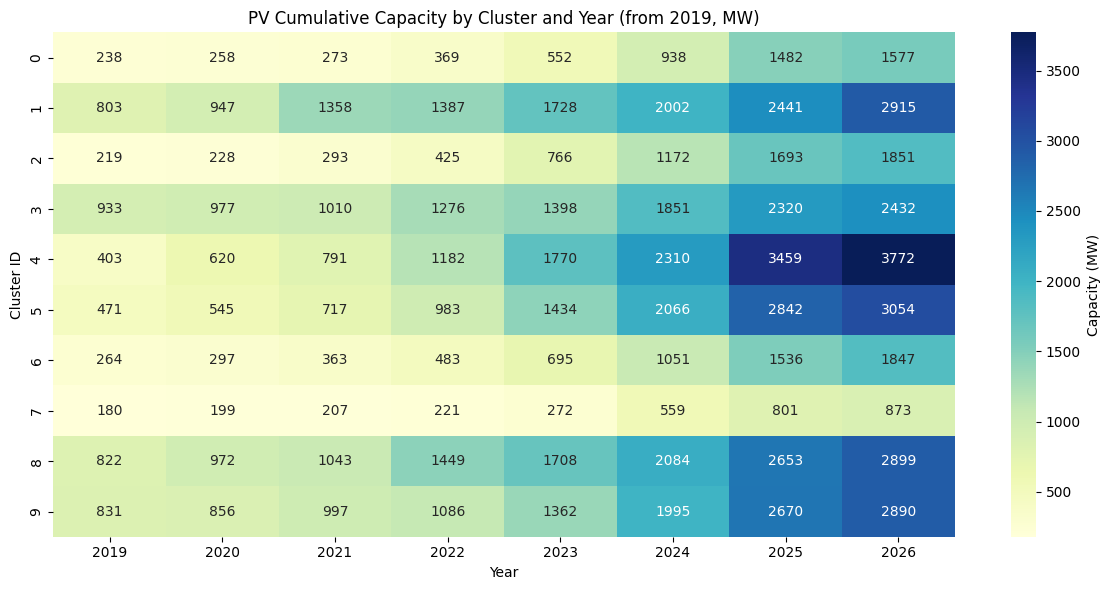

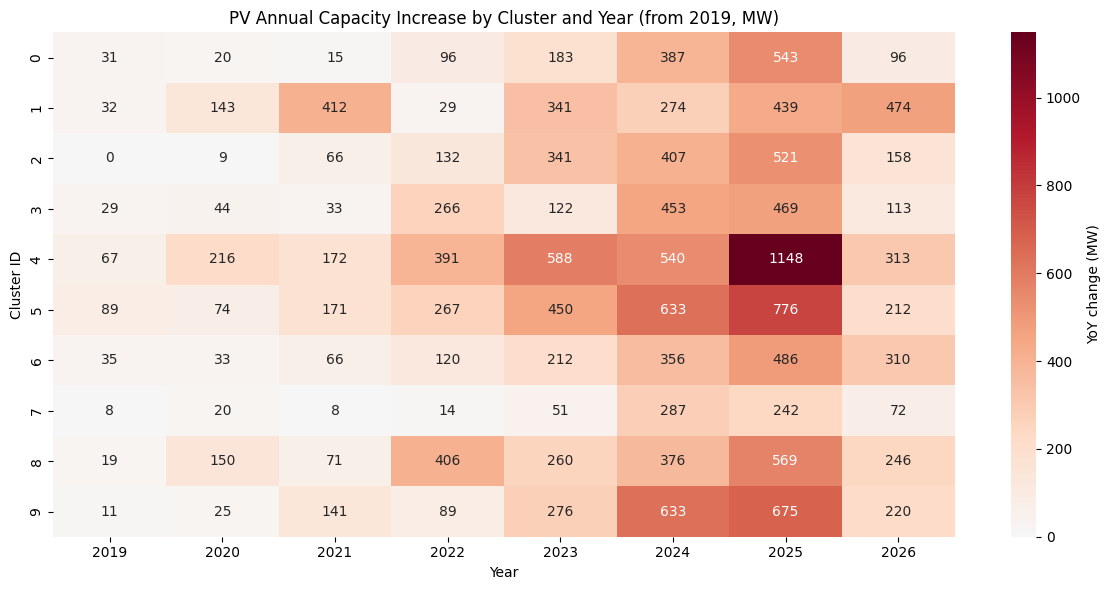

Median |YoY%|: 21.96%
Share clusters |YoY%|>10 in 2026: 20.00%


In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1) Basisdaten ueber die komplette Historie
df = df_gen_pv.copy()
df['Inbetriebnahmedatum der Einheit'] = pd.to_datetime(df['Inbetriebnahmedatum der Einheit'], errors='coerce')
df['year'] = df['Inbetriebnahmedatum der Einheit'].dt.year
df = df.dropna(subset=['year']).copy()

coord_cols = ['Koordinate: Breitengrad (WGS84)', 'Koordinate: Längengrad (WGS84)']
df = df.dropna(subset=coord_cols + ['Nettonennleistung der Einheit'])

X_all = df[coord_cols]

# 2) Referenz-Cluster einmal fitten (stabile IDs)
n_clusters = 10
kmeans_ref = KMeans(n_clusters=min(n_clusters, len(X_all)), random_state=42)
df['cluster_id'] = kmeans_ref.fit_predict(X_all)
centroids_ref = pd.DataFrame(
    kmeans_ref.cluster_centers_,
    columns=['lat', 'lon']
).reset_index().rename(columns={'index': 'cluster_id'})

# 3) Jaehrliche Zubaukapazitaet pro Referenz-Cluster
cap_year_cluster_pv = (
    df.groupby(['year', 'cluster_id'], as_index=False)['Nettonennleistung der Einheit']
      .sum()
      .rename(columns={'Nettonennleistung der Einheit': 'annual_addition_kw'})
)

# vollständiges Jahr-Cluster-Raster
years = sorted(cap_year_cluster_pv['year'].unique())
clusters = sorted(cap_year_cluster_pv['cluster_id'].unique())
full_idx = pd.MultiIndex.from_product([years, clusters], names=['year', 'cluster_id'])
cap_year_cluster_pv = (
    cap_year_cluster_pv.set_index(['year', 'cluster_id'])
    .reindex(full_idx, fill_value=0)
    .reset_index()
)

cap_year_cluster_pv = cap_year_cluster_pv.sort_values(['cluster_id', 'year']).reset_index(drop=True)
cap_year_cluster_pv['capacity_kw'] = cap_year_cluster_pv.groupby('cluster_id')['annual_addition_kw'].cumsum()

# YoY Delta
cap_year_cluster_pv['delta_kw'] = cap_year_cluster_pv.groupby('cluster_id')['capacity_kw'].diff().fillna(cap_year_cluster_pv['capacity_kw'])
cap_year_cluster_pv['delta_pct'] = cap_year_cluster_pv.groupby('cluster_id')['capacity_kw'].pct_change() * 100
cap_year_cluster_pv['delta_pct'] = cap_year_cluster_pv['delta_pct'].replace([np.inf, -np.inf], np.nan).fillna(0)

# 4) Visualisierung nur ab 2019
cap_year_cluster_vis = cap_year_cluster_pv[cap_year_cluster_pv['year'] >= 2019].copy()

pivot_cap = cap_year_cluster_vis.pivot(index='cluster_id', columns='year', values='capacity_kw')
plt.figure(figsize=(12, 6))
sns.heatmap(
    pivot_cap / 1000,
    cmap='YlGnBu',
    annot=True,
    fmt='.0f',
    cbar_kws={'label': 'Capacity (MW)'}
)
plt.title('PV Cumulative Capacity by Cluster and Year (from 2019, MW)')
plt.xlabel('Year')
plt.ylabel('Cluster ID')
plt.tight_layout()
plt.show()

# 5) Heatmap der jaehrlichen Zunahme ab 2019
pivot_delta_mw = cap_year_cluster_vis.pivot(index='cluster_id', columns='year', values='delta_kw')
plt.figure(figsize=(12, 6))
sns.heatmap(
    pivot_delta_mw / 1000,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.0f',
    cbar_kws={'label': 'YoY change (MW)'}
)
plt.title('PV Annual Capacity Increase by Cluster and Year (from 2019, MW)')
plt.xlabel('Year')
plt.ylabel('Cluster ID')
plt.tight_layout()
plt.show()

# 6) Entscheidungsmetrik: lohnt jaehrliches Update?
# Beispiel-Regel:
# - Median |YoY%| über alle Cluster/Jahre > 5%
# - oder im letzten sichtbaren Jahr > 30% Cluster mit |YoY%| > 10%
abs_yoy = cap_year_cluster_vis['delta_pct'].abs().dropna()
median_abs_yoy = abs_yoy.median() if len(abs_yoy) else 0

latest_year = int(cap_year_cluster_vis['year'].max())
share_large_changes = (
    cap_year_cluster_vis[cap_year_cluster_vis['year'] == latest_year]['delta_pct']
    .abs()
    .gt(10)
    .mean()
)

print(f"Median |YoY%|: {median_abs_yoy:.2f}%")
print(f"Share clusters |YoY%|>10 in {latest_year}: {share_large_changes:.2%}")

In [10]:
# add centroid coordinates to yearly cluster capacity export
centroids_pv = pd.DataFrame(centroids_pv, columns=['lat', 'lon']).reset_index().rename(columns={'index': 'cluster_id'})
cap_year_cluster_export_pv_since_2019 = cap_year_cluster_pv[cap_year_cluster_pv['year'] >= 2019].copy()
cap_year_cluster_export_pv_since_2019 = cap_year_cluster_export_pv_since_2019.merge(centroids_pv, on='cluster_id', how='left')
cap_year_cluster_export_pv_since_2019 = cap_year_cluster_export_pv_since_2019[['year', 'cluster_id', 'lat', 'lon', 'annual_addition_kw', 'capacity_kw', 'delta_kw', 'delta_pct']]
cap_year_cluster_export_pv_since_2019.to_csv("../data/processed/pv_cluster_yearly_capacity_since_2019.csv", index=False)
display(cap_year_cluster_export_pv_since_2019.head())

,year,cluster_id,lat,lon,annual_addition_kw,capacity_kw,delta_kw,delta_pct
0,2019,0,48.254208,9.954836,31212.0,238392.898,31212.0,15.065095
1,2020,0,48.254208,9.954836,19624.0,258016.898,19624.0,8.231789
2,2021,0,48.254208,9.954836,14655.0,272671.898,14655.0,5.679861
3,2022,0,48.254208,9.954836,95850.0,368521.898,95850.0,35.152137
4,2023,0,48.254208,9.954836,183218.0,551739.898,183218.0,49.716991


## Identify wind generation cluster with aggregated onshore(land) and offshore(see) data

* Use KMeans clustering to identify the clusters and their centroids
* Aggregate the net capacity within the clusters
* check the yearly growth for plausibility of the clustering

In [11]:
# use KMeans clustering to find the top 10 clusters of wind plants and their centroids and show the top 10 clusters of wind plants and their centroids and the wind plants belonging to each cluster on a map
kmeans_wind = KMeans(n_clusters=10, random_state=42)
X = df_gen_wind[['Koordinate: Breitengrad (WGS84)', 'Koordinate: Längengrad (WGS84)']]
kmeans_wind.fit(X)
centroids_wind = kmeans_wind.cluster_centers_

# create a dataframe with the top 10 clusters of wind plants and their centroids and the total capacity of the plants in each cluster
clusters = kmeans_wind.labels_
df_wind_clusters = pd.DataFrame({
    'Cluster': clusters,
    'Latitude': df_gen_wind['Koordinate: Breitengrad (WGS84)'],
    'Longitude': df_gen_wind['Koordinate: Längengrad (WGS84)'],
    'Nettonennleistung der Einheit': df_gen_wind['Nettonennleistung der Einheit']
})
df_wind_clusters = df_wind_clusters.groupby('Cluster').agg({
    'Latitude': 'mean',
    'Longitude': 'mean',
    'Nettonennleistung der Einheit': 'sum'
}).reset_index()
print("Top 10 clusters of wind plants with total capacity:")
display(df_wind_clusters)

# show the cluster centroids and the total capacity of the plants in each cluster on a map with the size of the marker proportional to the total capacity
m = folium.Map(location=[51.1657, 10.4515], 
                zoom_start=6, 
                tiles="CartoDB positron"
               )
for _, row in df_wind_clusters.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=row['Nettonennleistung der Einheit'] / 100000,  # adjust the radius for better visualization
        popup=f"Cluster {row['Cluster']} - Total Capacity: {row['Nettonennleistung der Einheit']} MW",
        color='green',
        fill=True,
        fill_color='green'
    ).add_to(m)
m.save("../reports/wind_clusters_capacity_map.html")


Top 10 clusters of wind plants with total capacity:


,Cluster,Latitude,Longitude,Nettonennleistung der Einheit
0,0,51.843002,8.497739,2175340
1,1,54.720161,13.918991,1624205
2,2,53.937550,7.291752,2381598
3,3,52.208403,10.491896,1608100
4,4,54.012429,9.762561,2414130
5,5,52.437985,13.964374,1272560
6,6,50.770402,6.943235,1383920
7,7,54.216299,6.212748,4220760
8,8,48.820484,9.737655,419120
9,9,52.474595,12.150012,1440381


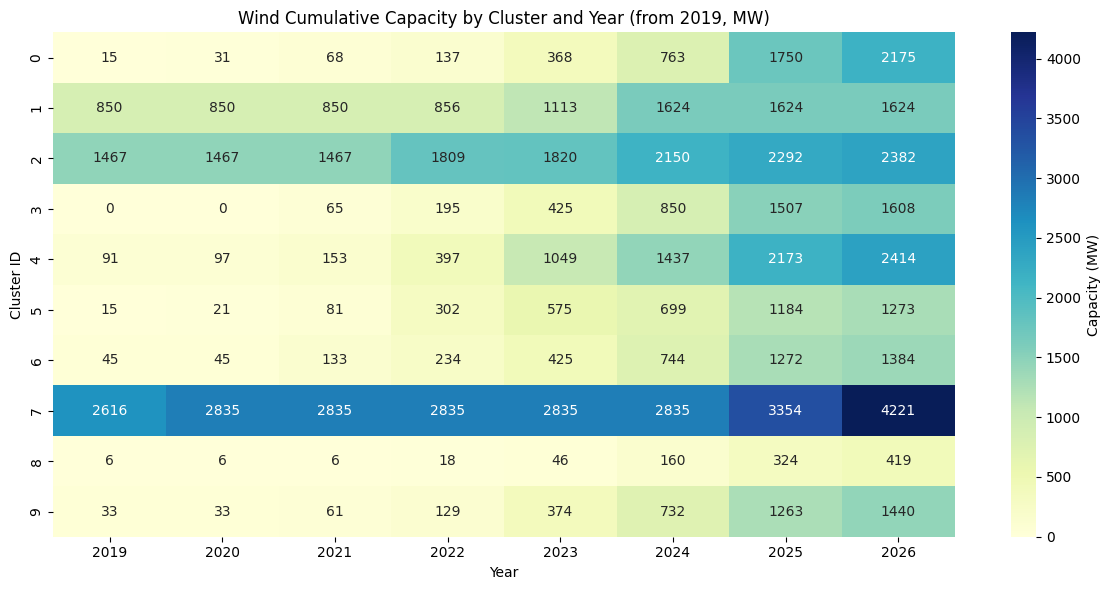

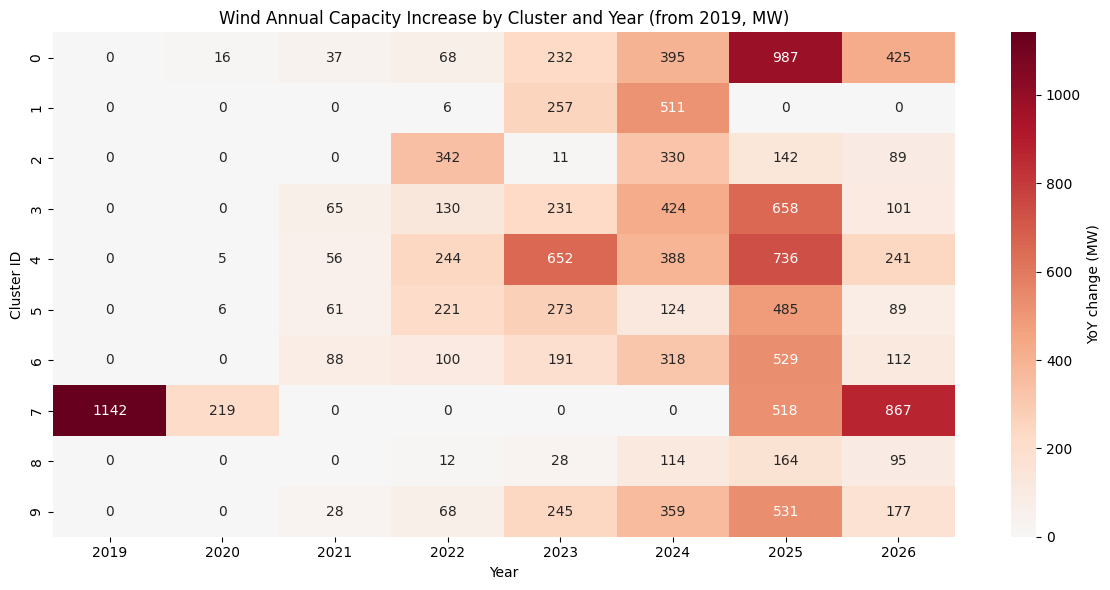

Median |YoY%|: 23.81%
Share clusters |YoY%|>10 in 2026: 50.00%


In [12]:
# 1) Basisdaten ueber die komplette Historie
df_wind = df_gen_wind.copy()
df_wind['Inbetriebnahmedatum der Einheit'] = pd.to_datetime(df_wind['Inbetriebnahmedatum der Einheit'], errors='coerce')
df_wind['year'] = df_wind['Inbetriebnahmedatum der Einheit'].dt.year
df_wind = df_wind.dropna(subset=['year']).copy()

coord_cols = ['Koordinate: Breitengrad (WGS84)', 'Koordinate: Längengrad (WGS84)']
df_wind = df_wind.dropna(subset=coord_cols + ['Nettonennleistung der Einheit'])

X_all = df_wind[coord_cols]

# 2) Referenz-Cluster einmal fitten (stabile IDs)
n_clusters = 10
kmeans_ref = KMeans(n_clusters=min(n_clusters, len(X_all)), random_state=42)
df_wind['cluster_id'] = kmeans_ref.fit_predict(X_all)
centroids_ref = pd.DataFrame(
    kmeans_ref.cluster_centers_,
    columns=['lat', 'lon']
).reset_index().rename(columns={'index': 'cluster_id'})

# 3) Jaehrliche Zubaukapazitaet pro Referenz-Cluster
cap_year_cluster_wind = (
    df_wind.groupby(['year', 'cluster_id'], as_index=False)['Nettonennleistung der Einheit']
      .sum()
      .rename(columns={'Nettonennleistung der Einheit': 'annual_addition_kw'})
)

# vollständiges Jahr-Cluster-Raster
years = sorted(cap_year_cluster_wind['year'].unique())
clusters = sorted(cap_year_cluster_wind['cluster_id'].unique())
full_idx = pd.MultiIndex.from_product([years, clusters], names=['year', 'cluster_id'])
cap_year_cluster_wind = (
    cap_year_cluster_wind.set_index(['year', 'cluster_id'])
    .reindex(full_idx, fill_value=0)
    .reset_index()
)

cap_year_cluster_wind = cap_year_cluster_wind.sort_values(['cluster_id', 'year']).reset_index(drop=True)
cap_year_cluster_wind['capacity_kw'] = cap_year_cluster_wind.groupby('cluster_id')['annual_addition_kw'].cumsum()

# YoY Delta
cap_year_cluster_wind['delta_kw'] = cap_year_cluster_wind.groupby('cluster_id')['capacity_kw'].diff().fillna(cap_year_cluster_wind['capacity_kw'])
cap_year_cluster_wind['delta_pct'] = cap_year_cluster_wind.groupby('cluster_id')['capacity_kw'].pct_change() * 100
cap_year_cluster_wind['delta_pct'] = cap_year_cluster_wind['delta_pct'].replace([np.inf, -np.inf], np.nan).fillna(0)

# 4) Visualisierung nur ab 2019
cap_year_cluster_vis = cap_year_cluster_wind[cap_year_cluster_wind['year'] >= 2019].copy()

pivot_cap = cap_year_cluster_vis.pivot(index='cluster_id', columns='year', values='capacity_kw')
plt.figure(figsize=(12, 6))
sns.heatmap(
    pivot_cap / 1000,
    cmap='YlGnBu',
    annot=True,
    fmt='.0f',
    cbar_kws={'label': 'Capacity (MW)'}
)
plt.title('Wind Cumulative Capacity by Cluster and Year (from 2019, MW)')
plt.xlabel('Year')
plt.ylabel('Cluster ID')
plt.tight_layout()
plt.show()

# 5) Heatmap der jaehrlichen Zunahme ab 2019
pivot_delta_mw = cap_year_cluster_vis.pivot(index='cluster_id', columns='year', values='delta_kw')
plt.figure(figsize=(12, 6))
sns.heatmap(
    pivot_delta_mw / 1000,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.0f',
    cbar_kws={'label': 'YoY change (MW)'}
)
plt.title('Wind Annual Capacity Increase by Cluster and Year (from 2019, MW)')
plt.xlabel('Year')
plt.ylabel('Cluster ID')
plt.tight_layout()
plt.show()

# 6) Entscheidungsmetrik: lohnt jaehrliches Update?
# Beispiel-Regel:
# - Median |YoY%| über alle Cluster/Jahre > 5%
# - oder im letzten sichtbaren Jahr > 30% Cluster mit |YoY%| > 10%
abs_yoy = cap_year_cluster_vis['delta_pct'].abs().dropna()
median_abs_yoy = abs_yoy.median() if len(abs_yoy) else 0

latest_year = int(cap_year_cluster_vis['year'].max())
share_large_changes = (
    cap_year_cluster_vis[cap_year_cluster_vis['year'] == latest_year]['delta_pct']
    .abs()
    .gt(10)
    .mean()
)

print(f"Median |YoY%|: {median_abs_yoy:.2f}%")
print(f"Share clusters |YoY%|>10 in {latest_year}: {share_large_changes:.2%}")

In [13]:
# add centroid coordinates to yearly wind cluster capacity export
centroids_wind = pd.DataFrame(centroids_wind, columns=['lat', 'lon']).reset_index().rename(columns={'index': 'cluster_id'})
cap_year_cluster_export_wind_since_2019 = cap_year_cluster_wind[cap_year_cluster_wind['year'] >= 2019].copy()
cap_year_cluster_export_wind_since_2019 = cap_year_cluster_export_wind_since_2019.merge(centroids_wind, on='cluster_id', how='left')
cap_year_cluster_export_wind_since_2019 = cap_year_cluster_export_wind_since_2019[['year', 'cluster_id', 'lat', 'lon', 'annual_addition_kw', 'capacity_kw', 'delta_kw', 'delta_pct']]
cap_year_cluster_export_wind_since_2019.to_csv("../data/processed/wind_cluster_yearly_capacity_since_2019.csv", index=False)
display(cap_year_cluster_export_wind_since_2019.head())

,year,cluster_id,lat,lon,annual_addition_kw,capacity_kw,delta_kw,delta_pct
0,2019,0,51.843002,8.497739,0,15160,0.0,0.000000
1,2020,0,51.843002,8.497739,15900,31060,15900.0,104.881266
2,2021,0,51.843002,8.497739,37100,68160,37100.0,119.446233
3,2022,0,51.843002,8.497739,68480,136640,68480.0,100.469484
4,2023,0,51.843002,8.497739,231520,368160,231520.0,169.437939


## Identify wind generation cluster with separated onshore(land) and offshore(see) data

* offshore - land
* onshore - see
* Steps
    - Use KMeans clustering to identify the clusters and their centroids
    - Aggregate the net capacity within the clusters
    - check the yearly growth for plausibility of the clustering

### Onshore - Land clustering

In [ ]:
# use KMeans clustering to find the top 10 clusters of wind plants and their centroids and show the top 10 clusters of wind plants and their centroids and the wind plants belonging to each cluster on a map
kmeans_wind_land = KMeans(n_clusters=10, random_state=42)
X = df_gen_wind_land[['Koordinate: Breitengrad (WGS84)', 'Koordinate: Längengrad (WGS84)']]
kmeans_wind_land.fit(X)
centroids_wind_land = kmeans_wind_land.cluster_centers_

# create a dataframe with the top 10 clusters of wind plants and their centroids and the total capacity of the plants in each cluster
clusters = kmeans_wind_land.labels_
df_wind_land_clusters = pd.DataFrame({
    'Cluster': clusters,
    'Latitude': df_gen_wind_land['Koordinate: Breitengrad (WGS84)'],
    'Longitude': df_gen_wind_land['Koordinate: Längengrad (WGS84)'],
    'Nettonennleistung der Einheit': df_gen_wind_land['Nettonennleistung der Einheit']
})
df_wind_land_clusters = df_wind_land_clusters.groupby('Cluster').agg({
    'Latitude': 'mean',
    'Longitude': 'mean',
    'Nettonennleistung der Einheit': 'sum'
}).reset_index()
print("Top 10 clusters of wind onshore plants with total capacity:")
display(df_wind_land_clusters)

# show the cluster centroids and the total capacity of the plants in each cluster on a map with the size of the marker proportional to the total capacity
m = folium.Map(location=[51.1657, 10.4515], 
                zoom_start=6, 
                tiles="CartoDB positron"
               )
for _, row in df_wind_land_clusters.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=row['Nettonennleistung der Einheit'] / 100000,  # adjust the radius for better visualization
        popup=f"Cluster {row['Cluster']} - Total Capacity: {row['Nettonennleistung der Einheit']} MW",
        color='green',
        fill=True,
        fill_color='green'
    ).add_to(m)
m.save("../reports/wind_onshore_clusters_capacity_map.html")


Top 10 clusters of wind onshore plants with total capacity:


,Cluster,Latitude,Longitude,Nettonennleistung der Einheit
0,0,54.144150,9.865936,2033130
1,1,52.253366,7.417368,1242820
2,2,52.544914,13.916800,1407240
3,3,48.735615,10.063631,334080
4,4,53.076917,8.966918,905420
5,5,52.245920,10.581706,1444900
6,6,49.664907,7.580589,570640
7,7,51.037630,6.355913,546980
8,8,52.488807,12.155722,1452381
9,9,51.414065,8.853566,1350980


In [18]:
# add centroid coordinates to yearly wind land cluster capacity export
centroids_wind_land  = pd.DataFrame(centroids_wind_land, columns=['lat', 'lon']).reset_index().rename(columns={'index': 'cluster_id'})
cap_year_cluster_export_wind_land_since_2019 = cap_year_cluster_wind[cap_year_cluster_wind['year'] >= 2019].copy()
cap_year_cluster_export_wind_land_since_2019 = cap_year_cluster_export_wind_land_since_2019.merge(centroids_wind_land, on='cluster_id', how='left')
cap_year_cluster_export_wind_land_since_2019 = cap_year_cluster_export_wind_land_since_2019[['year', 'cluster_id', 'lat', 'lon', 'annual_addition_kw', 'capacity_kw', 'delta_kw', 'delta_pct']]
cap_year_cluster_export_wind_land_since_2019.to_csv("../data/processed/wind_land_cluster_yearly_capacity_since_2019.csv", index=False)
display(cap_year_cluster_export_wind_land_since_2019.head(14))

,year,cluster_id,lat,lon,annual_addition_kw,capacity_kw,delta_kw,delta_pct
0,2019,0,54.144150,9.865936,0,15160,0.0,0.000000
1,2020,0,54.144150,9.865936,15900,31060,15900.0,104.881266
2,2021,0,54.144150,9.865936,37100,68160,37100.0,119.446233
3,2022,0,54.144150,9.865936,68480,136640,68480.0,100.469484
4,2023,0,54.144150,9.865936,231520,368160,231520.0,169.437939
5,2024,0,54.144150,9.865936,394560,762720,394560.0,107.170795
6,2025,0,54.144150,9.865936,987300,1750020,987300.0,129.444619
7,2026,0,54.144150,9.865936,425320,2175340,425320.0,24.303722
8,2019,1,52.253366,7.417368,0,849980,0.0,0.000000
9,2020,1,52.253366,7.417368,0,849980,0.0,0.000000


### Offshore - Sea clustering

In [25]:
# use KMeans clustering to find the top 4 clusters of wind plants and their centroids and show the top 3 clusters of wind plants and their centroids and the wind plants belonging to each cluster on a map
kmeans_wind_sea = KMeans(n_clusters=2, random_state=42)
X = df_gen_wind_sea[['Koordinate: Breitengrad (WGS84)', 'Koordinate: Längengrad (WGS84)']]
kmeans_wind_sea.fit(X)
centroids_wind_sea = kmeans_wind_sea.cluster_centers_

# create a dataframe with the top 4 clusters of wind plants and their centroids and the total capacity of the plants in each cluster
clusters = kmeans_wind_sea.labels_
df_wind_sea_clusters = pd.DataFrame({
    'Cluster': clusters,
    'Latitude': df_gen_wind_sea['Koordinate: Breitengrad (WGS84)'],
    'Longitude': df_gen_wind_sea['Koordinate: Längengrad (WGS84)'],
    'Nettonennleistung der Einheit': df_gen_wind_sea['Nettonennleistung der Einheit']
})
df_wind_sea_clusters = df_wind_sea_clusters.groupby('Cluster').agg({
    'Latitude': 'mean',
    'Longitude': 'mean',
    'Nettonennleistung der Einheit': 'sum'
}).reset_index()
print("Top 4 clusters of wind offshore plants with total capacity:")
display(df_wind_sea_clusters)

# show the cluster centroids and the total capacity of the plants in each cluster on a map with the size of the marker proportional to the total capacity
m = folium.Map(location=[51.1657, 10.4515], 
                zoom_start=6, 
                tiles="CartoDB positron"
               )
for _, row in df_wind_sea_clusters.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=row['Nettonennleistung der Einheit'] / 100000,  # adjust the radius for better visualization
        popup=f"Cluster {row['Cluster']} - Total Capacity: {row['Nettonennleistung der Einheit']} MW",
        color='green',
        fill=True,
        fill_color='green'
    ).add_to(m)
m.save("../reports/wind_offshore_clusters_capacity_map.html")


Top 4 clusters of wind offshore plants with total capacity:


,Cluster,Latitude,Longitude,Nettonennleistung der Einheit
0,0,54.192663,6.572168,6174018
1,1,54.813840,13.979021,1477525


In [20]:
# add centroid coordinates to yearly wind sea cluster capacity export
centroids_wind_sea  = pd.DataFrame(centroids_wind_sea, columns=['lat', 'lon']).reset_index().rename(columns={'index': 'cluster_id'})
cap_year_cluster_export_wind_sea_since_2019 = cap_year_cluster_wind[cap_year_cluster_wind['year'] >= 2019].copy()
cap_year_cluster_export_wind_sea_since_2019 = cap_year_cluster_export_wind_sea_since_2019.merge(centroids_wind_sea, on='cluster_id', how='left')
cap_year_cluster_export_wind_sea_since_2019 = cap_year_cluster_export_wind_sea_since_2019[['year', 'cluster_id', 'lat', 'lon', 'annual_addition_kw', 'capacity_kw', 'delta_kw', 'delta_pct']]
cap_year_cluster_export_wind_sea_since_2019.to_csv("../data/processed/wind_sea_cluster_yearly_capacity_since_2019.csv", index=False)
display(cap_year_cluster_export_wind_sea_since_2019.head(14))

,year,cluster_id,lat,lon,annual_addition_kw,capacity_kw,delta_kw,delta_pct
0,2019,0,54.0428,7.014411,0,15160,0.0,0.000000
1,2020,0,54.0428,7.014411,15900,31060,15900.0,104.881266
2,2021,0,54.0428,7.014411,37100,68160,37100.0,119.446233
3,2022,0,54.0428,7.014411,68480,136640,68480.0,100.469484
4,2023,0,54.0428,7.014411,231520,368160,231520.0,169.437939
5,2024,0,54.0428,7.014411,394560,762720,394560.0,107.170795
6,2025,0,54.0428,7.014411,987300,1750020,987300.0,129.444619
7,2026,0,54.0428,7.014411,425320,2175340,425320.0,24.303722
8,2019,1,54.8067,14.092373,0,849980,0.0,0.000000
9,2020,1,54.8067,14.092373,0,849980,0.0,0.000000
